---

# Paper


This assignment builds on the paper [*Artificial Intelligence, Algorithmic Pricing and Collusion*](https://ssrn.com/abstract=3304991) by Emilio Calvano, Giacomo Calzolari, Vincenzo Denicolò, and Sergio Pastorello (2019). The paper studies the behavior of pricing algorithms based on reinforcement learning in oligopolistic markets and analyzes whether such algorithms can learn to collude without explicit communication or coordination.
The paper analyzes a repeated price competition model in which firms use autonomous algorithms for making pricing decisions. The economic environment is a standard Bertrand-type oligopoly with homogeneous products, where firms repeatedly choose prices over time. Demand is deterministic in the baseline specification, and firms interact indefinitely, allowing for the possibility of history-dependent strategies.
Instead of assuming fully rational firms, the authors model firms as Q-learning agents, which is a widely used class of reinforcement-learning algorithms. These algorithms do not have prior knowledge of the demand structure, competitors’ strategies, or equilibrium outcomes. Instead, they learn optimal pricing behavior gradually through trial and error by updating expected payoffs associated with different price choices based on realized profits.
The central question of the paper is whether such algorithms, operating independently and without communication, can learn to sustain prices above the competitive Bertrand equilibrium. To address this question, the authors simulate repeated interactions between pricing algorithms and examine both the resulting price levels and the strategies that support them.
The main finding is that pricing algorithms systematically learn to charge supra-competitive prices, even though they are not programmed to collude and do not communicate with each other. The resulting prices are typically below the monopoly level but significantly above the one-shot Bertrand equilibrium. Importantly, the authors show that these outcomes are supported by collusive strategies, characterized by reward–punishment schemes in which deviations from high prices trigger temporary price wars, followed by a gradual return to cooperative pricing.


# Research question


While Calvano et al. (2019) show that pricing algorithms can learn to collude in repeated price competition, their baseline analysis largely focuses on symmetric firms, meaning that firms face identical cost structures and demand conditions. Although the authors do briefly explore robustness to asymmetries, the role of persistent cost heterogeneity is not analyzed in depth. Therefore, this assignment addresses the following research question:

**How does cost asymmetry between firms affect the emergence and sustainability of algorithmic collusion in repeated price competition when prices are set by reinforcement-learning algorithms?**

In particular, the analysis studies whether pricing algorithms are still able to coordinate on supra-competitive prices when firms have different marginal costs, and the role of firms’ patience is examined by varying the discount factor, in order to assess how the valuation of future profits interacts with cost asymmetries in sustaining collusive outcomes.

# Motivation


Understanding the role of cost asymmetry is economically important for several reasons. First, real-world markets are rarely symmetric: firms typically differ in production efficiency, technology, scale, or access to inputs. These differences translate into heterogeneous marginal costs, which may affect incentives to deviate from collusive outcomes.

Second, from a theoretical perspective, cost asymmetry is known to complicate collusion. In standard repeated-game models, asymmetric firms often face conflicting incentives, as low-cost firms have stronger incentives to undercut prices, while high-cost firms benefit more from collusive pricing. Whether autonomous learning algorithms can overcome these tensions without explicit coordination is therefore an open question.

Standard price competition theory delivers a sharp benchmark in the presence of cost asymmetries. In a one-shot homogeneous-product Bertrand setting or in the limiting case of (nearly) perfect substitutes a firm with a marginal-cost advantage has a strong incentive to aggressively undercut its rival, capture the entire market, and set prices close to the competitor’s marginal cost. As a result, the higher-cost firm is driven out of effective competition.

This intuition extends to dynamic environments in which firms fail to sustain collusion: cost asymmetry should intensify price competition and destabilize supra-competitive pricing, since the low-cost firm gains more from deviation while the high-cost firm has limited ability to discipline such behavior. From this perspective, one would expect asymmetric costs to lead to outcomes closer to the asymmetric Bertrand equilibrium rather than to sustained coordination.

# Preview of the answers


We first show that, under symmetric marginal costs, firms using Q-learning converge to prices close to the monopoly benchmark, thereby replicating the collusive outcome documented in Calvano et al. (2020).
We then find that allowing for asymmetric marginal costs within the same learning framework does not necessarily lead to substantially lower equilibrium prices for the cost-advantaged firm. Even when one firm faces a lower marginal cost, both firms tend to converge to prices close to the symmetric collusive benchmark under logit demand.
For the firm that is not cost-advantaged, we find that the rival’s lower cost has only a limited effect on its long-run price and price volatility. The non-advantaged firm neither exits the market nor engages in aggressive undercutting; instead, pricing remains relatively stable and well above the Nash benchmark.
While asymmetric costs are formally allowed in the original Calvano et al. model, they are primarily used there as a robustness check rather than as a focal point of analysis. By explicitly focusing on this dimension, we show that learning can partially offset cost differences. In particular, when firms are sufficiently patient, the value of future interaction sustains cooperative pricing incentives even in the presence of cost asymmetries. As a result, prices remain close to the collusive range despite differences in marginal costs, contrasting with standard static Bertrand intuition.

# Main assumptions 



We consider a market with two firms that repeatedly compete in prices. Demand is given by a logit specification, implying imperfect substitutability between products and a smooth demand response to price changes. Firms have constant marginal costs, which may be either symmetric or asymmetric across firms.
Firms do not observe the demand system or their rival’s cost directly. Instead, they adapt their pricing behavior over time using Q-learning, a model-free reinforcement learning algorithm. Each firm updates its value function based solely on realized profits and past actions, without strategic foresight or explicit coordination.
Prices are restricted to a finite and discrete grid, constructed around the Nash and monopoly benchmarks following Calvano et al. (2020). This restriction is necessary because standard Q-learning requires a finite action space; allowing for a continuum of prices would render the learning problem infeasible. Firms therefore choose prices from this fixed set in each period, rather than from a continuous price space.
Firms choose prices simultaneously in each period and discount future profits with a common discount factor. Learning parameters and discount factors are assumed to be symmetric across firms unless stated otherwise.
We abstract from entry and exit, capacity constraints, and cost shocks. All uncertainty arises from the learning process itself and the probabilistic nature of demand. The environment is stationary, and firms interact over an indefinitely long horizon.

# Model in the paper


We study a repeated pricing game between two firms that sell differentiated products. Time is discrete and indexed by $t = 0,1,2,\dots$. In each period, firms simultaneously choose prices $p_{1,t}$ and $p_{2,t}$ from a finite price grid. Firms interact over an infinite horizon and maximize the expected discounted sum of profits,
$$
\mathbb{E}\left[\sum_{t=0}^{\infty} \delta^{t}\,\pi_{i,t}\right],
\qquad \delta \in (0,1),
$$
where $\delta$ denotes the common discount factor.



Demand is modeled using a multinomial logit specification. Given prices $(p_1,p_2)$, consumers choose between the two products and an outside option. The quantity (market share) of firm $i \in \{1,2\}$ is given by
$$
q_i(p_1,p_2)
=
\frac{\exp\left(\frac{a_i - p_i}{\mu}\right)}
{\exp\left(\frac{a_0}{\mu}\right)
+ \exp\left(\frac{a_1 - p_1}{\mu}\right)
+ \exp\left(\frac{a_2 - p_2}{\mu}\right)}.
$$
The parameter $\mu > 0$ governs the degree of horizontal differentiation: smaller values of $\mu$ imply more price-sensitive demand. When $a_1 = a_2$, the demand system is symmetric across firms.



Firm $i$’s per-period profit is given by margin times quantity,
$$
\pi_i(p_1,p_2) = (p_i - c_i)\, q_i(p_1,p_2),
$$
where $c_i$ denotes firm $i$’s marginal cost. In the symmetric benchmark, $c_1 = c_2$. We allow for asymmetric marginal costs, $c_1 \neq c_2$, which implies that firms face different incentives even though products are symmetric from the consumer’s perspective.



Following Calvano et al.\ (2020), prices are restricted to a finite grid. First, we compute the Bertrand--Nash price $p^{N}$ as the fixed point of best responses, and the monopoly price $p^{M}$ as the price that maximizes joint profits. The admissible price set is then constructed as
$$
\mathcal{P}
=
\left\{p^{(1)},\dots,p^{(m)}\right\},
\qquad
p^{(k)} \in \left[(1-\xi)p^{N},\, (1+\xi)p^{M}\right],
$$
where $m$ denotes the number of grid points and $\xi > 0$ controls the width of the price interval. Restricting prices to a finite action space is necessary for the application of tabular Q-learning, which requires a finite set of actions.



Firms do not observe demand or profit functions directly. Instead, they use Q-learning to update beliefs about the long-run value of pricing actions. The state variable is given by the pair of prices chosen in the previous period. Let $Q_i(s,a)$ denote firm $i$’s estimate of the continuation value from choosing action $a$ in state $s$. The Q-values are updated according to
$$
Q_i(s_t,a_{i,t})
\leftarrow
(1-\alpha)\,Q_i(s_t,a_{i,t})
+
\alpha\left(
\pi_{i,t}
+
\delta \max_{a'} Q_i(s_{t+1},a')
\right),
$$
where $\alpha \in (0,1)$ is the learning rate.

In order to apply tabular Q-learning, the action and state spaces are assumed to be finite. Firms do not choose prices from a continuum; instead, prices are discretized into a finite grid $\mathcal{P}$ of size $m$, constructed around the Nash and monopoly benchmarks following Calvano et al. (2020).

The state variable summarizes the publicly observed outcome of the previous period and is given by the pair of prices chosen by the two firms. Formally, the state space is defined as
$$
\mathcal{S} = \mathcal{P} \times \mathcal{P},
$$
so that each state $s_t \in \mathcal{S}$ corresponds to the prices $(p_{1,t-1}, p_{2,t-1})$ chosen in the previous period. The state space is therefore finite with cardinality $|\mathcal{S}| = m^2$.

For each firm $i$, the Q-function is stored in tabular form as a matrix
$$
Q_i \in \mathbb{R}^{|\mathcal{S}|\times|\mathcal{P}|},
$$
where each entry $Q_i(s,a)$ represents the estimated discounted value of choosing price $a \in \mathcal{P}$ in state $s \in \mathcal{S}$ and then following the optimal continuation strategy. The finite state–action space is essential for the feasibility of tabular Q-learning and motivates the discretization of prices.


Action selection follows an $\varepsilon$-greedy rule. With probability $\varepsilon_t$, the firm experiments by choosing a random price, while with probability $1-\varepsilon_t$ it chooses a price that maximizes its current Q-values. The exploration rate decays over time according to
$$
\varepsilon_t = \exp(-\beta t),
$$
with $\beta > 0$.



While asymmetric marginal costs are formally allowed in Calvano et al.\ (2020), they are primarily used there as a robustness check. We explicitly focus on this dimension by studying how Q-learning dynamics interact with cost asymmetries. In particular, we analyze whether sufficiently patient firms can sustain cooperative pricing outcomes even when one firm has a cost advantage. This extension allows us to assess whether learning dynamics can partially offset cost differences and maintain prices close to the collusive benchmark, in contrast to static Bertrand predictions.


# Python code


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

This first block imports the libraries used throughout the simulation. NumPy is used for fast numerical work, vectorization, random number generation, and handling arrays such as the action grid and the payoff matrices. Matplotlib is used for producing the figures required in the assignment, such as time-series of prices or summary plots across parameter values. Pandas is used to store simulation outcomes in a reproducible way. Finally, `deque` from `collections` is a convenient data structure for keeping a rolling history without having to constantly copy arrays, which matters when the learning horizon is long.



In [2]:
a0 = 0.0
a1 = 2.0
a2 = 2.0
μ = 0.25

This block sets the demand-system parameters. We studied repeated price competition under logit demand, where each firm’s product has a mean utility term and consumers choose among product 1, product 2, and an outside option. Here, `a0` corresponds to the outside option’s mean utility, while `a1` and `a2` correspond to the mean utilities of the two products. The parameter $\mu$ is the logit scale parameter that governs how sensitive market shares are to price differences: a smaller $\mu$ implies that small price changes cause large shifts in market shares, which typically strengthens competitive pressure in the one-shot game but also affects the incentives within the repeated interaction. This is the standard baseline symmetric calibration used in the Calvano et al. setting.



In [3]:
m = 15
ξ = 0.1

The model is solved and simulated using a discrete action space: each firm chooses a price from a grid. The variable `m` sets the number of discrete price actions available to each firm. The parameter $(\xi)$ governs the width of the discrete price interval. This mirrors the practical approach in the paper, where the continuous pricing problem is approximated by a finite set of actions to make Q-learning feasible.


In [4]:
α = 0.125
δ = 0.95
β = 1e-5

This block defines the learning and discounting parameters of the Q-learning algorithm. The parameter $\alpha$ is the learning rate, controlling how strongly new information updates the current Q-values. The parameter $\delta$ is the discount factor, capturing how much the algorithm values future profits relative to current profits, a value close to one makes the agent more forward-looking, which is important in repeated games where punishment and reward schemes can sustain supra-competitive outcomes. Finally, $\beta$ governs the speed of decay in exploration: the comment indicates that exploration is scheduled as $\varepsilon_t = \exp(-\beta t)$, meaning that at the start the algorithm explores more and gradually becomes more exploitative as time passes. 



In [5]:
def demands(p1, p2):
    num1 = np.exp((a1 - p1) / μ)
    num2 = np.exp((a2 - p2) / μ)
    den  = np.exp(a0 / μ) + num1 + num2
    return num1 / den, num2 / den

def demand1(p1, p2):
    q1, _ = demands(p1, p2)
    return q1

def demand2(p1, p2):
    _, q2 = demands(p1, p2)
    return q2

def profits(p1, p2, c1, c2):
    q1, q2 = demands(p1, p2)
    return (p1 - c1) * q1, (p2 - c2) * q2

def profit1(p1, p2, c1):
    return (p1 - c1) * demand1(p1, p2)

def profit2(p1, p2, c2):
    return (p2 - c2) * demand2(p1, p2)


In [6]:
def make_env(c2, c1=1.0):
    grid = np.linspace(0.5, 3.0, 1001)

    def br1(p2):
        vals = np.array([profits(p1, p2, c1, c2)[0] for p1 in grid])
        return float(grid[np.argmax(vals)])

    def br2(p1):
        vals = np.array([profits(p1, p2, c1, c2)[1] for p2 in grid])
        return float(grid[np.argmax(vals)])
   
    p1, p2 = 1.0, 1.0
    for _ in range(500):
        p1_new = br1(p2)
        p2_new = br2(p1_new)
        if abs(p1_new - p1) < 1e-7 and abs(p2_new - p2) < 1e-7:
            break
        p1, p2 = p1_new, p2_new
    pN = 0.5 * (p1 + p2)
    
    best = (-1e18, None, None)
    for p1g in grid:
        q1, q2 = demands(p1g, grid)
        joint = (p1g - c1) * q1 + (grid - c2) * q2
        j = int(np.argmax(joint))
        if joint[j] > best[0]:
            best = (float(joint[j]), float(p1g), float(grid[j]))
    p1M, p2M = best[1], best[2]
    pM = 0.5 * (p1M + p2M)
    
    p_min = (1 - ξ) * pN
    p_max = (1 + ξ) * pM
    prices = np.linspace(p_min, p_max, m)
    
    π1 = np.zeros((m, m))
    π2 = np.zeros((m, m))
    for i in range(m):
        for j in range(m):
            r1, r2 = profits(prices[i], prices[j], c1, c2)
            π1[i, j] = r1
            π2[i, j] = r2

    return prices, π1, π2, pN, pM

The purpose of the function `make_env` is to construct the economic environment used by the Q-learning agents.
It defines a discrete price action space, computes profit payoffs for all possible price pairs,
and produces benchmark prices (Nash equilibrium and monopoly prices) used later for evaluation.

The function defines the economic environment in which the two pricing algorithms interact. At this stage, the core extension relative to the original paper already becomes explicit. Rather than imposing symmetric marginal costs by construction, the environment is parameterized by an arbitrary pair $(c_1, c_2)$. This design choice allows the model to accommodate cost asymmetries in a fully transparent and reproducible way, without altering the underlying demand structure. For any given cost configuration, the function constructs both the discrete price grid available to the agents and the corresponding stage-game profits for each firm at every possible price pair.

Demand is modeled using a standard multinomial logit specification. Given prices $(p_1, p_2)$, the terms `num1` and `num2` correspond to the exponentiated indirect utilities of the two products, where utility decreases in own price. The denominator additionally includes the outside option, ensuring that demand is expressed in terms of market shares. Firm $(i)$’s quantity is therefore given by
$$q_i(p_1,p_2) = \frac{\exp((a_i-p_i)/\mu)}{\exp(a_0/\mu)+\exp((a_1-p_1)/\mu)+\exp((a_2-p_2)/\mu)}.
$$
This demand system coincides with the baseline environment in the paper and preserves symmetry on the demand side when $(a_1 = a_2)$. In the logit demand system, each firm's demand is proportional to its exponential attractiveness.
The numerator represents the attractiveness of a product at a given price,
while the denominator normalizes demand across firms, ensuring smooth substitution and positive quantities.


Profits are computed as margin times quantity, $(\pi_i = (p_i - c_i) q_i)$. The crucial modification relative to the symmetric benchmark is that marginal costs now enter firm-specific profit functions. Firm 1’s profits depend on $(c_1)$, while firm 2’s profits depend on $(c_2)$. As a result, even when products are symmetric from the consumer’s perspective, incentives become asymmetric whenever $(c_1 \neq c_2)$. This asymmetry is precisely what the extension is designed to capture.

As in the original paper, the price grid used by the learning agents is anchored around theoretically meaningful benchmarks. In particular, the one-shot Bertrand–Nash equilibrium price and the joint-profit-maximizing (monopoly) price are used to define the relevant range of actions. In the continuous model, these benchmarks are characterized by optimization problems and fixed-point conditions, but closed-form solutions are generally unavailable under logit demand. The code therefore approximates both benchmarks numerically.

To this end, a fine auxiliary price grid, denoted `grid`, is constructed solely for approximation purposes. The vector defines a dense continuous price grid that is used exclusively for numerical optimization.
It allows the computation of approximate best-response prices by evaluating profits over a finely discretized interval.
The interval is chosen sufficiently wide to contain all relevant optimal prices.
This grid is not the action space used by the learning algorithms. The functions `br1` and `br2` implement numerical best-response mappings. For a given rival price, each firm evaluates its profit over all candidate prices in `grid` and selects the price that maximizes profit. This procedure corresponds directly to the definition of best responses in a Bertrand pricing game.

An approximation to the one-shot Bertrand–Nash equilibrium is then obtained as a fixed point of these best responses. Starting from an initial price vector $(p_1, p_2) = (1,1)$, the algorithm iteratively updates prices: firm 1 best-responds to the current price of firm 2, after which firm 2 best-responds to the updated price of firm 1. This process continues until both prices converge within a very tight tolerance level.

The resulting fixed point $(p_1^N, p_2^N)$ provides a numerical approximation to the Nash equilibrium of the continuous pricing game. The code then defines a single benchmark price $(p^N)$ as the average of the two equilibrium prices. In the symmetric benchmark studied in the paper, this averaging step is redundant because both firms choose the same equilibrium price. Under asymmetric costs, however, equilibrium prices may differ. Taking the average produces a single scalar benchmark that can still be used to define a common discretization range for both firms.

The next step computes a joint-profit benchmark by identifying the price pair that maximizes total industry profits, $(\pi_1 + \pi_2)$. Conceptually, this corresponds to the monopoly outcome or, in the context of the repeated game, the fully collusive pricing profile.

The code implements a grid search over candidate price pairs. For each candidate value of firm 1’s price, denoted `p1g`, joint profits are evaluated over all possible prices of firm 2 using the fine approximation grid. The call `demands(p1g, grid)` exploits vectorization by passing the entire grid as an array, allowing demand and profits to be computed efficiently for all candidate values of $(p_2)$ in a single operation. For each `p1g`, the algorithm selects the value of $(p_2)$ that maximizes joint profits, compares the resulting maximum to the best outcome found so far, and updates the stored price pair whenever a higher joint profit is obtained.

This procedure yields a numerical approximation $(p_1^M, p_2^M)$ to the joint-profit-maximizing prices. As in the Nash case, the code defines a single monopoly benchmark price $(p^M)$ as the average of the two firm-specific prices. The monopoly (or cartel) price maximizes joint profits, defined as the sum of both firms' profits.
This benchmark represents the fully collusive outcome and provides an upper reference against which learned prices can be compared.
When costs differ, the profit-maximizing prices for the two firms generally do not coincide. Averaging again produces a single scalar reference point that can be used to define the bounds of the discretized action space.

With both benchmarks in hand, the function proceeds to construct the discrete price grid that the Q-learning agents will actually use. Following the approach in the paper, the grid is anchored around economically meaningful limits. The lower bound is set slightly below the Nash benchmark, while the upper bound extends slightly above the monopoly benchmark. The parameter $(\xi)$ controls how far the grid reaches beyond these benchmarks in either direction. The final result is an evenly spaced grid of $(m)$ prices ranging from $(p_{\min})$ to $(p_{\max})$.

The economic rationale behind this construction is that the action space must include both competitive and cooperative prices. Prices near the Nash benchmark allow the algorithms to reproduce competitive behavior, while prices near the monopoly benchmark make it possible for the agents to discover and sustain supra-competitive outcomes if such behavior is profitable in the repeated interaction.

In the final step, the environment is translated into objects that are convenient for reinforcement learning. For every pair of discrete actions $(i,j)$, where $(i)$ indexes firm 1’s chosen price and $(j)$ indexes firm 2’s chosen price, the corresponding stage-game profits are computed and stored in payoff matrices $\Pi_1$ and $\Pi_2$. These matrices provide a complete discrete representation of the stage game.

Once these payoff matrices are constructed, in each period, the agents choose price indices rather than continuous prices, and rewards are read directly from the matrices. This step therefore constitutes an explicit mapping from the analytical profit functions in the paper to the discrete numerical objects used in Python. Profit matrices are precomputed for all possible price combinations.
Each matrix entry corresponds to one firm's profit given a pair of discrete price choices.

The function ultimately returns the discrete price grid, the two payoff matrices, and the benchmark prices $(p^N)$ and $(p^M)$. These outputs are used both to simulate learning dynamics and to interpret outcomes, for instance by comparing long-run average prices to competitive and collusive benchmarks.













In [7]:
C2_VALUES = [1.0, 0.7]
env_cache = {c2v: make_env(c2v, c1=1.0) for c2v in C2_VALUES}
print("env_cache ready:", list(env_cache.keys()))


def run_q(
    c2,
    seed=0,
    c1=1.0,
    max_T=880_000,
    check_every=5_000,
    stable_needed=100_000,
    window=200_000
):
    rng = np.random.default_rng(seed)

    prices, π1, π2, pN, pM = env_cache[c2]

    S = m * m
    A = m

    def s_idx(a1_prev, a2_prev):
        return a1_prev * m + a2_prev

    def eps_t(t):
        return np.exp(-β * t)

    def eps_greedy(Qrow, eps):
        if rng.random() < eps:
            return int(rng.integers(0, A))
        mx = Qrow.max()
        best = np.flatnonzero(Qrow == mx)
        return int(rng.choice(best))

    exp_π1 = π1.mean(axis=1)
    exp_π2 = π2.mean(axis=0)
    init1 = exp_π1 / (1 - δ)
    init2 = exp_π2 / (1 - δ)

    Q1 = np.empty((S, A))
    Q2 = np.empty((S, A))
    Q1[:] = init1
    Q2[:] = init2

    a1_prev = int(rng.integers(0, m))
    a2_prev = int(rng.integers(0, m))
    s = s_idx(a1_prev, a2_prev)

    a1_path = deque(maxlen=window)
    a2_path = deque(maxlen=window)

    prev_pol1 = None
    prev_pol2 = None
    stable = 0
    converged_t = None

    for t in range(max_T):
        eps = eps_t(t)
        a1 = eps_greedy(Q1[s, :], eps)
        a2 = eps_greedy(Q2[s, :], eps)

        r1 = π1[a1, a2]
        r2 = π2[a1, a2]
        s_next = s_idx(a1, a2)

        Q1[s, a1] = (1 - α) * Q1[s, a1] + α * (r1 + δ * Q1[s_next, :].max())
        Q2[s, a2] = (1 - α) * Q2[s, a2] + α * (r2 + δ * Q2[s_next, :].max())

        a1_path.append(a1)
        a2_path.append(a2)

        s = s_next

        if (t + 1) % check_every == 0:
            pol1 = Q1.argmax(axis=1)
            pol2 = Q2.argmax(axis=1)

            if prev_pol1 is not None and np.array_equal(pol1, prev_pol1) and np.array_equal(pol2, prev_pol2):
                stable += check_every
            else:
                stable = 0
                prev_pol1 = pol1.copy()
                prev_pol2 = pol2.copy()

            if stable >= stable_needed:
                converged_t = t + 1
                break

    arr1 = np.fromiter(a1_path, dtype=int)
    arr2 = np.fromiter(a2_path, dtype=int)

    w0 = int(0.9 * len(arr1))
    p1_last = prices[arr1[w0:]]
    p2_last = prices[arr2[w0:]]

    def modal_share(a_window):
        counts = np.bincount(a_window, minlength=m)
        return counts.max() / counts.sum() if counts.sum() > 0 else np.nan

    p1_path = prices[arr1]
    p2_path = prices[arr2]

    return {
        "c1": c1,
        "c2": c2,
        "pN_avg": pN,
        "pM_avg": pM,
        "converged": converged_t is not None,
        "t_conv": converged_t,
        "last10_avg_p1": float(p1_last.mean()) if len(p1_last) else np.nan,
        "last10_avg_p2": float(p2_last.mean()) if len(p2_last) else np.nan,
        "last10_std_p1": float(p1_last.std()) if len(p1_last) else np.nan,
        "last10_std_p2": float(p2_last.std()) if len(p2_last) else np.nan,
        "last10_modal_p1": float(modal_share(arr1[w0:])) if len(arr1) else np.nan,
        "last10_modal_p2": float(modal_share(arr2[w0:])) if len(arr2) else np.nan,
        "p1_path": p1_path,
        "p2_path": p2_path
    }


rows = []
for c2v in C2_VALUES:
    for seed in range(2):
        rows.append(run_q(c2v, seed=seed, c1=1.0))

df = pd.DataFrame(rows)
df

env_cache ready: [1.0, 0.7]


,c1,c2,pN_avg,pM_avg,converged,t_conv,last10_avg_p1,last10_avg_p2,last10_std_p1,last10_std_p2,last10_modal_p1,last10_modal_p2,p1_path,p2_path
0,1.0,1.0,1.4725,1.925,True,640000,1.832219,1.831846,0.028946,0.033073,0.98815,0.98835,"[1.8345535714285717, 1.8345535714285717, 1.834...","[1.8345535714285717, 1.8345535714285717, 1.834..."
1,1.0,1.0,1.4725,1.925,True,600000,1.886423,1.886887,0.042489,0.038582,0.97960,0.98170,"[1.4384285714285716, 1.7779642857142859, 1.891...","[1.8911428571428575, 1.6647857142857145, 1.891..."
2,1.0,0.7,1.3525,1.920,True,705000,1.854625,1.726593,0.024592,0.027951,0.99390,0.99370,"[1.8563571428571433, 1.8563571428571433, 1.856...","[1.7285357142857145, 1.7285357142857145, 1.728..."
3,1.0,0.7,1.3525,1.920,True,605000,1.788059,1.723682,0.038946,0.044098,0.98385,0.98210,"[1.792446428571429, 1.792446428571429, 1.79244...","[1.7285357142857145, 1.7285357142857145, 1.728..."


This block constructs multiple economic environments corresponding to different values of firm 2’s marginal cost while holding firm 1’s cost fixed at $(c_1 = 1.0)$. This is the central implementation of the “different costs” extension. By varying $(c_2)$, the analysis compares learning outcomes across symmetric and asymmetric cost structures, such as the benchmark case $(c_2 = 1.0)$ and an asymmetric case $(c_2 = 0.7)$, where firm 2 is more efficient. In all cases, demand parameters remain symmetric, so any differences in behavior can be traced directly to cost asymmetry.

The dictionary `env_cache` stores, for each value of $(c_2)$, the corresponding environment object $(\text{prices}, \Pi_1, \Pi_2, p^N, p^M)$. Caching serves an important computational purpose. Constructing the environment requires numerical best-response calculations and payoff-matrix construction. By precomputing and storing these objects, the simulation avoids redundant computation and ensures that identical parameter configurations always correspond to identical environments.

The code then defines the function that runs the Q-learning simulation for a given cost configuration, with reproducibility ensured through a fixed random seed. The parameter `max_T` sets an upper bound on the number of repeated-game periods, while `check_every` determines how frequently the code checks whether behavior has stabilized. The parameter `stable_needed` specifies how long stability must persist before the algorithm is deemed to have converged, and `window` determines the size of the rolling window used to compute long-run outcomes.

At the start of the simulation routine, the precomputed environment associated with the chosen value of $(c_2)$ is loaded from `env_cache`. This retrieves the discrete price grid, the payoff matrices, and the benchmark prices $(p^N)$ and $(p^M)$.

The dimensions of the reinforcement-learning problem are then defined. Each firm maintains a Q-table that assigns expected discounted profits to every state-action pair. Initial Q-values reflect neutral prior beliefs before learning begins.
Each firm has $(A = m)$ available actions, corresponding to the $(m)$ discrete prices in the grid. The state space has size $(S = m^2)$, because the state is defined as the previous period’s joint action $(a_{1,t-1}, a_{2,t-1})$. This representation mirrors the Markov structure emphasized in the paper, where strategies condition on past play.

The helper function `s_idx` maps a two-dimensional state $(a_{1,t-1}, a_{2,t-1})$ into a single integer index between $(0)$ and $(m^2 - 1)$. This step is a programming convenience that allows the Q-tables to be stored as standard two-dimensional arrays of shape $(S, A)$, rather than as higher-dimensional objects.

The function `eps_t` implements the exploration schedule $(\varepsilon_t = \exp(-\beta t))$. Early in the simulation, exploration is frequent, allowing agents to experiment broadly. Over time, the exploration probability decays toward zero, and agents increasingly follow the policies implied by their learned Q-values. This slow, gradual decay is consistent with the computational design in the paper, which emphasizes unsupervised learning over long horizons.

The function `eps_greedy` translates the exploration probability into an action choice. Action selection follows an $\varepsilon$-greedy rule. With probability $\varepsilon_t$, the agent explores by choosing an action uniformly at random.
Otherwise, it exploits current knowledge by selecting an action that maximizes the Q-values
in the current state. When multiple actions yield the same maximum value, ties are broken randomly.

The Q-tables are initialized in a way that is economically meaningful rather than starting from an arbitrary zero baseline. The idea is to approximate the discounted value of random play. The arrays $\exp(\pi_1)$ and $\exp(\pi_2)$ compute expected one-period profits when the opponent’s action is uniformly distributed over the price grid. For firm 1, this is done by averaging profits across firm 2’s actions conditional on firm 1’s choice, and analogously for firm 2. Dividing these expected profits by $(1 - \delta)$ yields the infinite-horizon discounted value of receiving that payoff every period. The entire Q-table for each agent is initialized with these values, ensuring that initial beliefs are neither artificially pessimistic nor optimistic.

After initialization, the code sets the initial conditions and prepares the objects needed for diagnostics. The simulation begins from a random previous joint action $(a_{1,-1}, a_{2,-1})$. Since the state is defined as the previous period’s action pair, this choice generates an initial state index without imposing any special starting history or coordination.

The deques `a1_path` and `a2_path` store the most recent `window` action indices chosen by each firm. Because these deques have a fixed maximum length, older observations are automatically discarded as new ones are added. This design keeps memory usage bounded even when the learning horizon spans hundreds of thousands of periods. Economically, the rolling window is important because the analysis focuses on long-run behavior after learning has largely settled, rather than on early transient dynamics.

Convergence tracking is implemented through the variables `prev_pol1` and `prev_pol2`, which store the greedy policies implied by the Q-tables at the previous checkpoint. Every `check_every` periods, the code computes the current greedy policies `pol1 = Q1.argmax(axis=1)` and `pol2 = Q2.argmax(axis=1)` and compares them to `prev_pol1` and `prev_pol2`. If both policies are unchanged, the counter `stable` is incremented by `check_every`; otherwise it is reset to zero and the stored policies are updated. Convergence is declared once the greedy policies remain unchanged for at least `stable_needed` periods, reflecting the idea that learning has converged when strategies stop evolving rather than when prices merely happen to be high temporarily.



The core of the routine is the Q-learning loop. In each period $(t)$, both firms select actions using the $(\varepsilon_t)$-greedy rule. Given the current state index, the relevant row of each firm’s Q-table provides the value estimates for all possible actions. Once actions are chosen, realized one-period profits $(r_1, r_2)$ are read directly from the precomputed payoff matrices. The reward received by each firm in a given period is equal to its realized one-period profit. Rewards are read directly from the precomputed payoff matrices, ensuring that learning is based on the exact economic environment. This discrete representation of the stage game avoids recomputing demand and profits during learning and ensures that the repeated interaction exactly reflects the underlying economic environment.

The next state is defined as the current joint action $(a_{1,t}, a_{2,t})$. This implements the Markov structure of the repeated game, in which today’s play becomes tomorrow’s state. The Q-values are then updated using the standard one-step Q-learning recursion. For firm $(i)$, the update takes the form
$$Q_i(s, a_i) \leftarrow (1 - \alpha) Q_i(s, a_i) + \alpha \left[ r_i + \delta \max_{a_i'} Q_i(s', a_i') \right]$$

The Q-value update combines past beliefs with newly observed outcomes. The learning rate $\alpha$ controls how rapidly beliefs are revised, while the discount factor $\delta$ determines the importance of future expected profits.

The continuation value $\left(\max_{a'_i} Q_i(s',a'_i)\right)$ reflects the assumption that each firm expects to choose its own best action in the next period. This learning rule corresponds exactly to the reinforcement-learning mechanism emphasized in the paper. After updating, the chosen actions are appended to the rolling windows and the state index is updated.

The learning dynamics are implemented using a tabular Q-learning algorithm. Firms repeatedly interact over a long horizon and update their pricing strategies based on realized profits and observed price histories.

Several parameters control the duration of the simulation and the detection of convergence. Stability is assessed by checking whether pricing behavior remains approximately unchanged over multiple evaluation windows.
Every `check_every` periods, the code evaluates whether learning has stabilized. Convergence is evaluated in terms of strategy stability rather than price realizations. Learning is considered complete when the greedy policies implied by the Q-tables remain unchanged over multiple consecutive checkpoints. It computes the greedy policies implied by the current Q-tables by selecting, for each state, the action that maximizes the Q-values. The resulting arrays summarize the strategies that the agents would follow if exploration were shut down at that point. Stability is declared if both firms’ greedy policies are identical to those from the previous checkpoint. The variable `stable` counts how long this condition has held consecutively. Once the policies have remained unchanged for at least `stable_needed` periods, the simulation records the convergence time and exits the loop.

This stopping rule operationalizes the idea that an equilibrium-like outcome has been reached. What matters is not momentary price realizations but the emergence of a stationary pair of strategies that the algorithms continue to reinforce.

When the learning loop ends either because convergence is detected or because the maximum horizon is reached the rolling-window action histories are converted into NumPy arrays. Attention then shifts to the final segment of these histories. The code defines a cutoff at 90% of the window length and extracts the last 10% of observations. Long-run outcomes are computed using only the final 10\% of observations in the rolling window. This focuses attention on post-learning behavior and excludes early exploratory dynamics. This final segment serves as a proxy for long-run behavior after learning has largely settled.

An additional diagnostic statistic is constructed to measure the degree of action concentration. The function `modal_share` computes the fraction of times the most frequently chosen action appears within a window. Values close to one indicate near-deterministic pricing at a single grid point, which is typical of stable learned strategies when exploration becomes negligible. Lower values indicate dispersed behavior or ongoing exploration.

The arrays `p1_path` and `p2_path` map the stored action indices into actual price levels using the discrete price grid. These price paths are useful for visualization, as they allow the learning dynamics to be plotted directly and compared to the Nash and monopoly benchmarks.

The function returns a structured object containing both parameters and outcomes. The benchmark prices $(p^N)$ and $(p^M)$ are included to facilitate interpretation of learned prices relative to competitive and cooperative reference points. The indicators `converged` and `t_conv` report whether convergence occurred under the stopping rule and, if so, when it happened. The “last10” statistics summarize long-run behavior in terms of average prices, residual volatility, and action concentration. Finally, the full price paths are returned so that the dynamics of learning can be analyzed and plotted.

The final block executes the simulation design. Firm 1’s cost is fixed at $(c_1 = 1.0)$, while firm 2’s cost varies across the values in `C2_VALUES`. This directly implements the extension away from the symmetric benchmark: $(c_2 = 1.0)$ corresponds to the baseline case studied in the paper, while $(c_2 = 0.7)$ introduces a more efficient firm and asymmetric pricing incentives despite symmetric demand. For each cost configuration, the simulation is repeated across multiple random seeds. Because Q-learning dynamics are inherently stochastic, running multiple seeds helps distinguish systematic effects of cost asymmetry from randomness in the learning process.


The table summarizes the long-run learning outcomes across symmetric and asymmetric cost environments. In all configurations, the algorithm converges under the policy-stability criterion, although convergence times are long, reflecting the slow exploration decay and the high-dimensional state space. In the symmetric benchmark case $(c_1 = c_2 = 1.0)$, both firms learn to charge prices that lie well above the Nash benchmark but below the monopoly level, with very small dispersion in the final window and high modal shares close to one. This indicates near-deterministic pricing at a single grid point and effective tacit coordination. When firm 2 becomes more efficient $(c_2 = 0.7)$, convergence still occurs, but the learned prices become asymmetric: firm 2 systematically sets lower prices than firm 1, consistent with its lower marginal cost. Price dispersion remains low, and modal shares remain high, indicating stable learned strategies rather than cycling or mixed behavior.





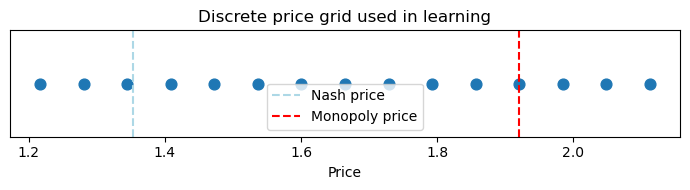

In [8]:
prices, π1, π2, pN, pM = make_env(c2=0.7, c1=1.0)

plt.figure(figsize=(7,2))

plt.scatter(prices, np.zeros_like(prices), s=60)
plt.axvline(pN, linestyle="--", label="Nash price", color= "lightblue")
plt.axvline(pM, linestyle="--", label="Monopoly price", color= "red")

plt.yticks([])
plt.xlabel("Price")
plt.title("Discrete price grid used in learning")
plt.legend()
plt.tight_layout()
plt.show()

This line reconstructs the economic environment for a specific asymmetric-cost configuration in which firm 1 has marginal cost $(c_1 = 1.0)$ and firm 2 has marginal cost $(c_2 = 0.7)$. The function `make_env` returns the discrete price grid used by the learning algorithms, the corresponding payoff matrices for both firms, and the benchmark average prices associated with the Bertrand–Nash equilibrium and the joint-profit-maximizing outcome.

The purpose here is not to run the learning algorithm again, but to isolate and visualize the action space faced by the firms. By fixing costs explicitly, the figure that follows can be interpreted as depicting the exact pricing environment used in the asymmetric simulations discussed earlier.

The next block initializes a new figure and plots the discrete price grid as points on a horizontal line, where each dot corresponds to one admissible price that a firm can choose in any period of the repeated game.

Presenting the grid in this way makes the discretization explicit. Rather than allowing firms to choose prices from a continuous interval, the learning problem restricts actions to a finite set of $(m)$ prices. This restriction is essential for Q-learning, as it guarantees a finite action space and allows value functions to be stored and updated numerically. The figure therefore visualizes the key approximation that links the analytical pricing model to its computational implementation.

Vertical dashed lines are added to indicate the two benchmark prices used to construct the grid. The Nash price corresponds to the competitive outcome of the one-shot pricing game, while the monopoly price corresponds to the cooperative outcome that maximizes joint profits.

Placing these benchmarks directly on the grid highlights how the discretization is grounded in economic theory. The grid is deliberately chosen to extend slightly below the Nash benchmark and slightly above the monopoly benchmark, ensuring that both competitive and supra-competitive price levels are feasible actions for the learning algorithms. This design choice is crucial: if high prices were excluded from the grid, the algorithms could not learn collusive outcomes, regardless of the incentives generated by repeated interaction.

The figure illustrates that the discrete action space is sufficiently rich to support economically meaningful pricing behavior. Both the Nash and monopoly benchmark prices lie strictly inside the grid rather than at its boundaries, ensuring that neither competitive nor collusive outcomes are mechanically imposed by the discretization. Instead, the learning algorithms must actively select among neighboring grid points to approximate these benchmarks. The relatively fine spacing of prices around the Nash and monopoly levels implies that convergence to intermediate, quasi-collusive prices reflects genuine strategic learning rather than coarse grid effects. At the same time, the finite nature of the grid clarifies why learned prices often cluster tightly at a single point: once exploration diminishes, the algorithm reinforces the locally optimal grid price closest to the desired continuous benchmark.


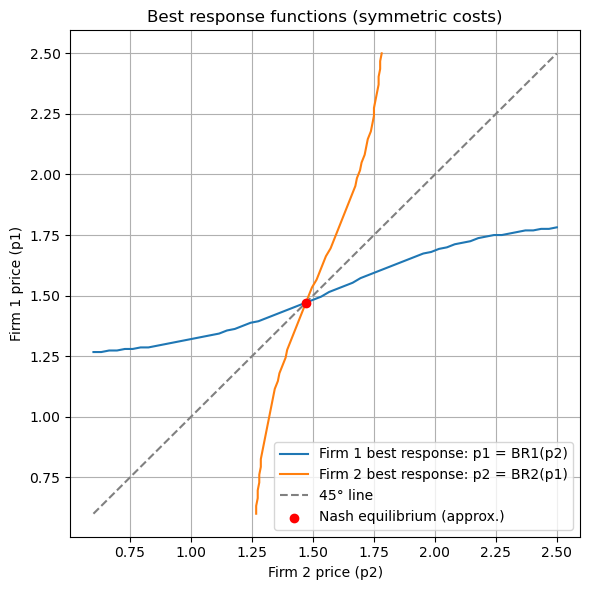

In [9]:
c = 1.0
p_grid = np.linspace(0.6, 2.5, 300)

p2_vals = np.linspace(0.6, 2.5, 60)
br1 = []
for p2 in p2_vals:
    π1_list = [profit1(p1, p2, c) for p1 in p_grid]
    br1.append(p_grid[int(np.argmax(π1_list))])

p1_vals = np.linspace(0.6, 2.5, 60)
br2 = []
for p1 in p1_vals:
    π2_list = [profit2(p1, p2, c) for p2 in p_grid]
    br2.append(p_grid[int(np.argmax(π2_list))])

p1, p2 = 1.0, 1.0
for _ in range(500):
    p1_new = p_grid[int(np.argmax([profit1(p, p2, c) for p in p_grid]))]
    p2_new = p_grid[int(np.argmax([profit2(p1_new, p, c) for p in p_grid]))]

    if abs(p1_new - p1) < 1e-7 and abs(p2_new - p2) < 1e-7:
        break

    p1, p2 = p1_new, p2_new

pN1, pN2 = p1, p2

plt.figure(figsize=(6, 6))

plt.plot(p2_vals, br1, label="Firm 1 best response: p1 = BR1(p2)")

plt.plot(br2, p1_vals, label="Firm 2 best response: p2 = BR2(p1)")

plt.plot(p_grid, p_grid, "--", color="gray", label="45° line")

plt.scatter(pN2, pN1, color="red", zorder=5, label="Nash equilibrium (approx.)")

plt.xlabel("Firm 2 price (p2)")
plt.ylabel("Firm 1 price (p1)")
plt.title("Best response functions (symmetric costs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

This block numerically approximates the one-shot Bertrand pricing benchmark under symmetric marginal costs. Both firms are assigned the same marginal cost, $(c = 1.0)$, and demand is governed by the multinomial logit structure used throughout the assignment. Each firm’s demand is therefore its market share as a function of both prices. In this implementation, demand enters through the profit functions `profit1` and `profit2`, which evaluate each firm’s payoff given a pair of prices $(p_1, p_2)$ and the common marginal cost.

Profits are defined as margin times quantity. For firm 1, profits take the form

$$
\pi_1(p_1, p_2) = (p_1 - c)\, q_1(p_1, p_2),
$$

with an analogous expression for firm 2.  Writing profits in this way clarifies the logic of best responses: for any given rival price, each firm’s optimal choice is the price that maximizes its own profit.

A fine grid of candidate prices is constructed next. Best-response functions are approximated numerically by evaluating profits at each grid point and selecting the price that yields the highest payoff. This discretization allows the best-response mappings to be computed without relying on closed-form solutions, which are generally unavailable under logit demand.

The code then computes firm 1’s best-response function $\mathrm{BR}_1(p_2)$. The array `p2_vals` contains the set of competitor prices at which firm 1’s response is evaluated. For each value of $(p_2)$, the code computes firm 1’s profit over all candidate values of $(p_1)$ in `p_grid` and selects the profit-maximizing price using `np.argmax`. These optimal prices are stored sequentially, forming a numerical approximation to firm 1’s best-response mapping.

Economically, this function describes how firm 1 optimally adjusts its price as the rival’s price changes. When the competitor raises its price, firm 1 typically faces weaker competitive pressure and can increase its own price without losing as much demand. The precise shape of the response is governed by the curvature and substitution patterns implied by the logit demand system.

Firm 2’s best-response function $\mathrm{BR}_2(p_1)$ is constructed in an analogous manner. For each candidate value of firm 1’s price, the code evaluates firm 2’s profit across all candidate prices for firm 2 and selects the price that maximizes profit. The resulting list `br2` represents firm 2’s optimal pricing response to the rival’s price.

Because the benchmark environment is symmetric in both demand parameters and marginal costs, the two best-response mappings are theoretically identical up to a relabeling of firms. In practice, small discrepancies can arise because best responses are computed on discretized grids and plotted in a common coordinate system. The key diagnostic is therefore whether the two curves intersect close to the 45-degree line and yield an equilibrium with $(p_1^N \approx p_2^N)$.

The next block computes a numerical approximation to the Nash equilibrium using fixed-point iteration on the best-response functions. Starting from an initial price pair $(p_1, p_2) = (1.0, 1.0)$, the algorithm alternates between firms: firm 1 best-responds to the current value of $(p_2)$, after which firm 2 best-responds to the updated value of $(p_1)$. Repeating this procedure produces convergence to a pair of prices at which each firm’s choice is a best response to the other.

In a symmetric game, the Nash equilibrium satisfies $(p_1^N = p_2^N)$ in theory. The code nevertheless stores both components $(p_1^N, p_2^N)$, which also provides a numerical check on how closely the computed outcome satisfies symmetry. The purpose of this computation is to locate the intersection point of the two best-response functions, which defines the equilibrium of the one-shot Bertrand pricing game under logit demand.

The final block plots the best-response functions and highlights the Nash equilibrium. Firm 1’s best response is plotted with the competitor’s price on the horizontal axis and firm 1’s optimal price on the vertical axis. Firm 2’s best-response curve is plotted in the same coordinate system by reversing the axes appropriately, allowing both mappings to be displayed together and making their intersection visible.

A 45-degree line is included as a visual reference. In a symmetric equilibrium where $(p_1 = p_2)$, the Nash point lies on this line. The red marker identifies the numerically computed equilibrium price.






From an economic perspective, this figure provides an intuitive depiction of the one-shot competitive benchmark. In the repeated-game simulations, outcomes close to this intersection correspond to competitive pricing, while outcomes substantially above it indicate that the learning dynamics have supported prices higher than those predicted by the static Bertrand equilibrium.


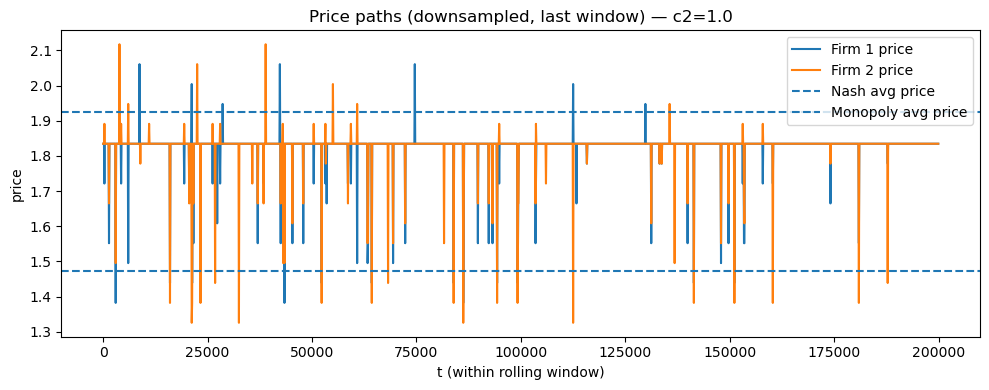

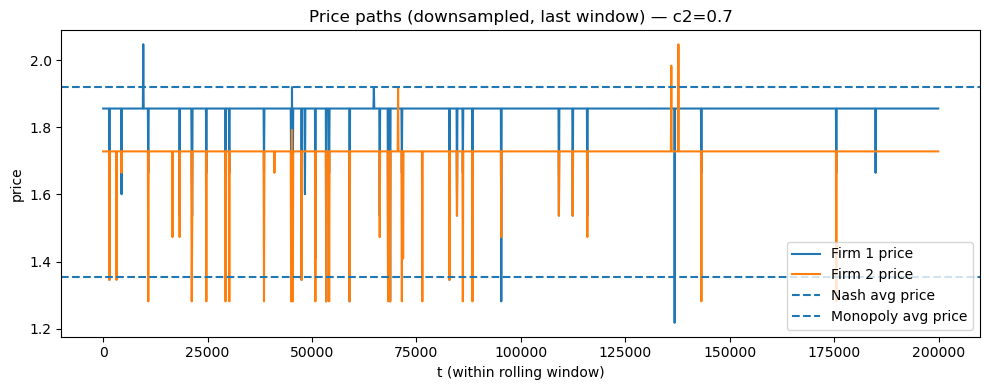

In [10]:
for c2v in [1.0, 0.7]:
    res = run_q(c2v, seed=0, c1=1.0)
    p1_path = res["p1_path"]
    p2_path = res["p2_path"]

    Tplot = len(p1_path)
    step = max(1, Tplot // 2000)
    tgrid = np.arange(0, Tplot, step)

    plt.figure(figsize=(10,4))
    plt.plot(tgrid, p1_path[::step], label="Firm 1 price")
    plt.plot(tgrid, p2_path[::step], label="Firm 2 price")
    plt.axhline(res["pN_avg"], linestyle="--", label="Nash avg price")
    plt.axhline(res["pM_avg"], linestyle="--", label="Monopoly avg price")
    plt.xlabel("t (within rolling window)")
    plt.ylabel("price")
    plt.title(f"Price paths (downsampled, last window) — c2={c2v}")
    plt.legend()
    plt.tight_layout()
    plt.show()

This block initiates the figure-producing stage of the analysis by running the learning simulation for two distinct cost configurations. The case $(c_2 = 1.0)$ corresponds to the symmetric-cost benchmark studied in the original paper, while $(c_2 = 0.7)$ introduces cost asymmetry by making firm 2 more efficient than firm 1. For each configuration, the function `run_q` returns a structured set of outcomes, including the realized price paths over the stored rolling window. Extracting `p1_path` and `p2_path` yields the sequences of prices chosen by each firm during the late stage of the simulation, which is the phase intended to reflect behavior after learning has largely stabilized.

The next step prepares the time axis and applies downsampling to ensure that the resulting plots remain readable and computationally efficient. The rolling window may contain up to `window` observations, which would produce an excessively dense time series if plotted in full. The variable `step` therefore selects roughly 2,000 evenly spaced observations by retaining every `step`-th element of the stored paths. The use of `max(1, …)` guarantees that the step size is never zero, preventing errors in short samples. The array `tgrid` then provides the corresponding time index, which should be interpreted as indexing positions within the late-stage window rather than calendar time.

For each cost configuration, a separate figure is created and the two firms’ price paths are plotted on the same axes using the downsampled series. Horizontal reference lines are added to anchor the time series to economically meaningful benchmarks. The line corresponding to $(p^N)$ represents the average Bertrand–Nash price computed in the environment builder, while the line corresponding to $(p^M)$ represents the average joint-profit-maximizing (monopoly) price. Including both benchmarks allows us to visually evaluate whether learned pricing behavior is closer to competitive pricing, closer to collusive pricing, or somewhere in between.

The near-constant price paths indicate that exploration has effectively vanished and that the algorithms have converged to stable pricing strategies.The resulting price paths confirm that learning has largely stabilized in both environments and that late-stage behavior is highly concentrated. In the symmetric-cost case $(c_2 = 1.0)$, both firms’ prices cluster tightly around a common level that lies well above the Nash benchmark and below the monopoly benchmark, with only occasional downward deviations. These rare price cuts are short-lived and do not trigger sustained competitive dynamics, indicating that the learned strategies support a stable, quasi-collusive outcome rather than cycling or punishment phases. When costs become asymmetric $(c_2 = 0.7)$, prices remain similarly stable, but a clear ordering emerges: the more efficient firm 2 consistently sets lower prices than firm 1, while both firms still price above the Nash benchmark. Importantly, the overall price level remains elevated despite firm 2’s stronger incentive to undercut, suggesting that cost asymmetry affects relative pricing rather than undermining coordination altogether. These visual patterns are consistent with the long-run statistics reported above, including high modal shares and low price dispersion in the final window.



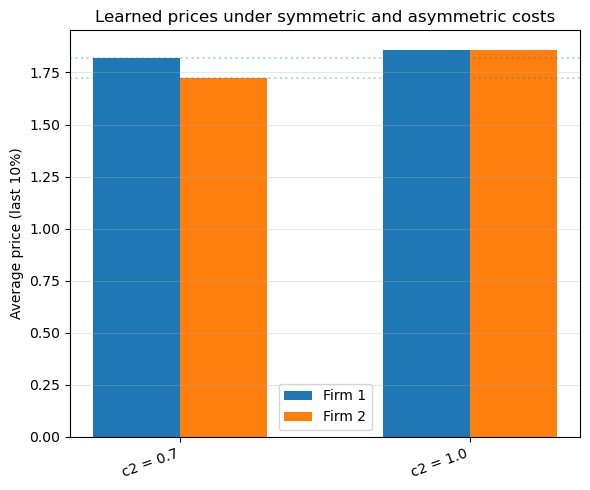

In [11]:
avg_df = (
    df.groupby("c2")
      .agg(
          avg_p1=("last10_avg_p1", "mean"),
          avg_p2=("last10_avg_p2", "mean")
      )
      .reset_index()
)

plt.figure(figsize=(6, 5))

x = range(len(avg_df))

plt.bar([i - 0.15 for i in x], avg_df["avg_p1"], width=0.3, label="Firm 1")
plt.bar([i + 0.15 for i in x], avg_df["avg_p2"], width=0.3, label="Firm 2")

plt.axhline(avg_df["avg_p1"].min(), linestyle=":", alpha=0.3)
plt.axhline(avg_df["avg_p2"].min(), linestyle=":", alpha=0.3)

plt.xticks(x, [f"c2 = {c2}" for c2 in avg_df["c2"]], rotation=20, ha="right")
plt.ylabel("Average price (last 10%)")
plt.title("Learned prices under symmetric and asymmetric costs")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


This block aggregates the simulation outcomes across random seeds. Each row of the dataframe `df` corresponds to a single run of the learning algorithm for a given cost configuration and seed. Because Q-learning involves stochastic exploration and random tie-breaking, individual runs can differ even when all parameters are held fixed. Aggregating across seeds is therefore necessary to separate systematic effects of cost asymmetry from idiosyncratic learning paths.

To summarize long-run behavior, the code groups the data by firm 2’s marginal cost $(c_2)$ and computes the mean of the late-stage average prices, `last10_avg_p1` and `last10_avg_p2`, across seeds. The resulting dataframe `avg_df` contains one row per cost configuration and reports the average learned price for each firm in the final phase of the simulation. Averaging across seeds smooths out idiosyncratic learning paths and reveals the systematic effect of cost asymmetry on pricing behavior.The reported averages should therefore be interpreted as typical long-run outcomes rather than as results from any single realization.


The next block initializes a new figure and defines the horizontal positions for the bars. Each value of $(c_2)$ corresponds to one category on the x-axis. The variable `x` indexes these categories numerically, allowing the bars for the two firms to be positioned with small horizontal offsets.

A grouped bar chart is then constructed. For each cost configuration, two bars are displayed side by side: one representing firm 1’s average learned price and the other representing firm 2’s average learned price. The horizontal offsets ensure that the bars do not overlap.

The aggregated results in bar chart highlight how cost asymmetry translates into systematic pricing differences in the learned outcomes. In the symmetric benchmark 
$(c_2 = 1.0)$, both firms converge to nearly identical average prices, reflecting the preservation of symmetry in the learning dynamics and reinforcing the interpretation of a coordinated, quasi-collusive outcome. By contrast, when firm 2 becomes more efficient $(c_2 = 0.7)$, a clear pricing wedge emerges: firm 2 sets a lower average price than firm 1, consistent with its lower marginal cost. Importantly, however, both firms’ prices remain elevated relative to competitive benchmarks, indicating that the cost advantage affects relative pricing levels rather than inducing a breakdown of supra-competitive pricing.



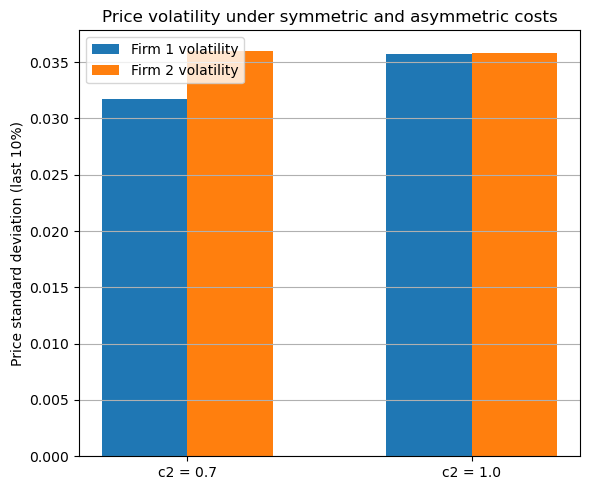

In [12]:
vol_df = (
    df.groupby("c2")
      .agg(
          std_p1=("last10_std_p1", "mean"),
          std_p2=("last10_std_p2", "mean")
      )
      .reset_index()
)

plt.figure(figsize=(6, 5))

plt.bar([i - 0.15 for i in x], vol_df["std_p1"], width=0.3, label="Firm 1 volatility")
plt.bar([i + 0.15 for i in x], vol_df["std_p2"], width=0.3, label="Firm 2 volatility")

plt.xticks(x, [f"c2 = {c2}" for c2 in vol_df["c2"]])
plt.ylabel("Price standard deviation (last 10%)")
plt.title("Price volatility under symmetric and asymmetric costs")

plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

This block constructs a dataframe that summarizes price volatility during the late stage of learning. As in the previous analysis of average prices, results are aggregated across random seeds to abstract from idiosyncratic randomness in individual learning paths. For each value of firm 2’s marginal cost $(c_2)$, the code computes the mean of the standard deviations of prices observed over the final 10% of the rolling window, separately for firm 1 and firm 2.

The standard deviation of prices within this final window serves as a measure of stability in the learned behavior. Low volatility indicates that the algorithm repeatedly selects the same, or nearly the same, price, which is consistent with convergence to a stable strategy or an equilibrium-like outcome. Higher volatility, in contrast, points to ongoing fluctuations in pricing. Such fluctuations may arise from residual exploration, punishment-and-forgiveness dynamics in the repeated game, or instability introduced by asymmetric incentives.

The subsequent block visualizes these volatility measures using a grouped bar chart analogous to the one used for average prices. For each cost configuration, two bars are shown side by side, representing the price volatility of firm 1 and firm 2 respectively. This visualization is informative because similar average prices can conceal very different underlying dynamics. Two firms may exhibit nearly identical mean prices in the late-stage window, yet one may cycle between several grid points while the other prices almost deterministically.

The volatility bar chart results indicate that learning converges to highly stable pricing behavior in both the symmetric and asymmetric cost environments. Across cost configurations, price volatility in the final window is low and of similar magnitude for both firms, suggesting that late-stage behavior is largely deterministic rather than characterized by persistent cycling or experimentation. In the symmetric benchmark $(c_2 = 1.0)$, the near-identical volatilities of the two firms reinforce the interpretation of a stable, symmetric outcome. When costs are asymmetric $(c_2 = 0.7)$, firm 2 exhibits slightly higher volatility than firm 1, consistent with stronger incentives to deviate or undercut given its lower marginal cost. However, the difference is modest, indicating that cost asymmetry does not fundamentally destabilize the learned pricing regime.







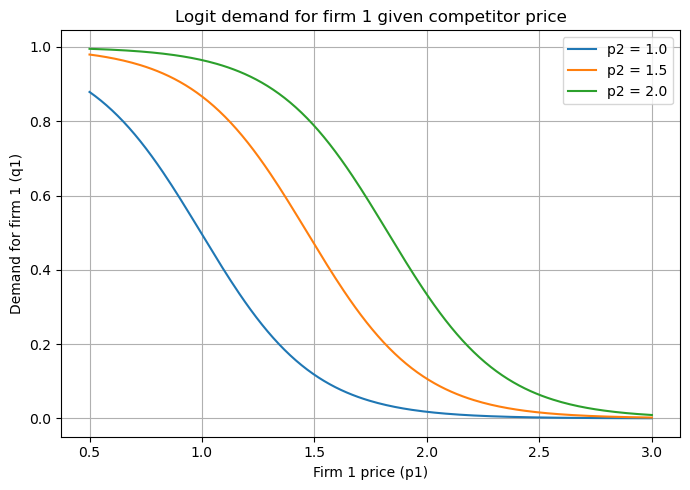

In [13]:
p1_grid = np.linspace(0.5, 3.0, 200)

plt.figure(figsize=(7,5))

for p2 in [1.0, 1.5, 2.0]:
    q1 = [demand1(p1, p2) for p1 in p1_grid]
    plt.plot(p1_grid, q1, label=f"p2 = {p2}")

plt.xlabel("Firm 1 price (p1)")
plt.ylabel("Demand for firm 1 (q1)")
plt.title("Logit demand for firm 1 given competitor price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

This function defines firm 1’s demand as a function of its own price $(p_1)$ and the competitor’s price $(p_2)$, using the same multinomial logit demand system that underlies the entire model. The numerator captures the exponentiated utility of firm 1’s product, which decreases in its own price. The denominator aggregates the utilities of both firms’ products and the outside option, ensuring that demand is bounded between zero and one and can be interpreted as a market share.

Writing this demand function explicitly helps clarify the link between the analytical model and the simulations. The same demand structure governs one-shot profits, numerical best responses, and the incentives faced by the learning algorithms. Isolating it in a standalone function allows us to see directly how prices map into quantities, independently of the reinforcement-learning machinery.

The next line constructs a fine grid of possible prices for firm 1. The grid spans the economically relevant price region used elsewhere in the assignment, ranging from relatively low prices to high prices that substantially reduce demand.

The following block generates the demand curves. For each fixed value of the competitor’s price $(p_2)$, firm 1’s demand is evaluated across all values of $(p_1)$ on the grid and the resulting relationship is plotted.

The plotted demand curves clearly illustrate the strategic structure embedded in the logit specification. For any given competitor price, firm 1’s demand declines smoothly as its own price increases, reflecting the gradual substitution toward the rival product and the outside option. As the competitor’s price rises from 
$p_2 = 1.0$ to 
$p_2 = 2.0$, firm 1’s demand curve shifts outward and becomes flatter over a wider range of prices, indicating that firm 1 can sustain higher prices while retaining substantial market share when the rival prices aggressively. This outward shift captures the essence of strategic complementarity in pricing: a firm’s optimal price is increasing in its competitor’s price. In the context of the learning results, these demand curves help explain why coordinated high-price outcomes are attractive to both firms, but also why a cost-advantaged firm faces a stronger temptation to undercut because small price reductions translate into relatively large demand gains when the rival’s price is high.


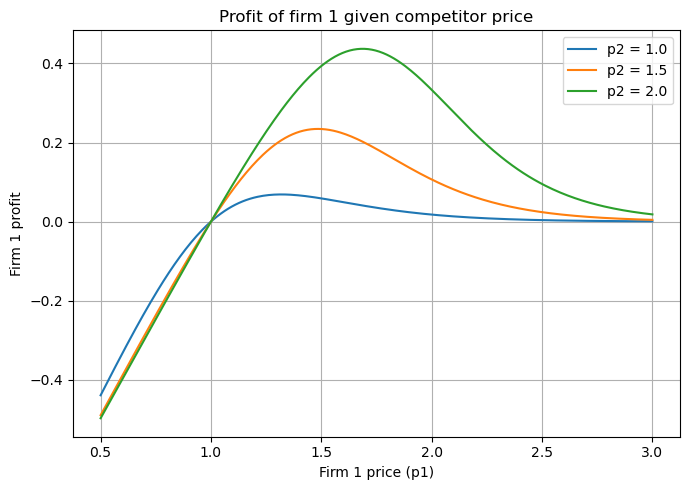

In [14]:

c1 = 1.0
c2 = 0.7
p1_grid = np.linspace(0.5, 3.0, 300)

plt.figure(figsize=(7,5))

for p2 in [1.0, 1.5, 2.0]:
    π1 = [profit1(p1, p2, c1) for p1 in p1_grid]
    plt.plot(p1_grid, π1, label=f"p2 = {p2}")

plt.xlabel("Firm 1 price (p1)")
plt.ylabel("Firm 1 profit")
plt.title("Profit of firm 1 given competitor price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

This function defines firm 1’s demand as a function of both firms’ prices under the multinomial logit specification. As before, the numerator captures the exponentiated utility of firm 1’s product, while the denominator aggregates the utilities of both products and the outside option. The resulting expression gives firm 1’s market share as a smooth function of relative prices.

Including this demand function explicitly reinforces the connection between the analytical model and the numerical illustrations. The same demand structure governs one-shot profits, numerical best responses, and the incentives that the reinforcement-learning algorithms face in the repeated game. Making it explicit allows us to see directly how price competition translates into demand without relying on the learning code.

The next block defines firm 1’s profit as the product of its per-unit margin and its demand. Marginal cost enters directly through the margin term $(p_1 - c_1)$. Because $(c_1)$ is held fixed in this illustration, differences across profit curves are driven entirely by how demand responds to changes in both firms’ prices. This formulation highlights why cost asymmetry matters: even when demand is symmetric, differences in marginal costs alter the trade-off between price and quantity that determines profit maximization.

A fine grid of possible prices for firm 1 is then constructed. The grid spans the economically relevant price range used throughout the assignment.

The subsequent block generates profit curves for firm 1 under different values of the competitor’s price $(p_2)$. For each fixed $(p_2)$, firm 1’s profit is evaluated over the entire grid of own prices and the resulting relationship is plotted.

The profit curves make the one-shot pricing incentives particularly transparent. For each fixed competitor price, firm 1’s profit is strictly concave in its own price, reflecting the standard trade-off between higher margins and lower demand. As the competitor’s price increases, the profit curve shifts upward and the profit-maximizing price rises, illustrating strategic complementarity in prices under logit demand. At low values of $p_2$, firm 1’s optimal price is relatively low and maximum profits are modest, while higher rival prices substantially increase both the level of attainable profits and the gains from pricing less aggressively. This structure clarifies why high-price outcomes are attractive in the repeated game: when both firms maintain elevated prices, each operates near the peak of its profit curve. At the same time, the curvature of the profit function shows that small unilateral deviations can yield immediate gains, especially when the rival’s price is high, which explains the persistent temptation to undercut that the learning algorithms must overcome to sustain coordinated pricing.




In [15]:
c1 = 1.0
c2 = 0.7
SEED = 0
MAX_T = 400_000
WINDOW = 50_000

δ_VALUES = [0.95, 0.85, 0.75, 0.65]


def run_q(prices, π1, π2, δ, seed=SEED, max_T=MAX_T, window=WINDOW):
    rng = np.random.default_rng(seed)

    A = len(prices)
    S = A * A

    def s_idx(a1, a2):
        return a1 * A + a2

    def eps_t(t):
        return np.exp(-β * t)

    exp_π1 = π1.mean(axis=1)  
    exp_π2 = π2.mean(axis=0)  
    
    Q1 = np.tile(exp_π1 / (1 - δ), (S, 1))
    Q2 = np.tile(exp_π2 / (1 - δ), (S, 1))

    a1 = int(rng.integers(0, A))
    a2 = int(rng.integers(0, A))
    s = s_idx(a1, a2)

    hist1 = deque(maxlen=window)
    hist2 = deque(maxlen=window)

    for t in range(max_T):
        eps = eps_t(t)

        if rng.random() < eps:
            a1_new = int(rng.integers(0, A))
        else:
            row = Q1[s]
            a1_new = int(rng.choice(np.flatnonzero(row == row.max())))

        if rng.random() < eps:
            a2_new = int(rng.integers(0, A))
        else:
            row = Q2[s]
            a2_new = int(rng.choice(np.flatnonzero(row == row.max())))

        r1 = π1[a1_new, a2_new]
        r2 = π2[a1_new, a2_new]

        s_next = s_idx(a1_new, a2_new)

        Q1[s, a1_new] = (1 - α) * Q1[s, a1_new] + α * (r1 + δ * Q1[s_next].max())
        Q2[s, a2_new] = (1 - α) * Q2[s, a2_new] + α * (r2 + δ * Q2[s_next].max())

        hist1.append(a1_new)
        hist2.append(a2_new)

        s = s_next

    arr1 = np.array(hist1)
    arr2 = np.array(hist2)

    cut1 = int(0.9 * len(arr1))
    cut2 = int(0.9 * len(arr2))

    p1_last = prices[arr1[cut1:]]
    p2_last = prices[arr2[cut2:]]

    return {
        "δ": δ,
        "avg_p1": float(p1_last.mean()),
        "avg_p2": float(p2_last.mean()),
        "std_p1": float(p1_last.std()),
        "std_p2": float(p2_last.std()),
    }

prices, π1, π2, pN, pM = make_env(c2=c2, c1=c1)

rows = []
for δ in δ_VALUES:
    res = run_q(prices, π1, π2, δ)
    res["pN"] = pN
    res["pM"] = pM
    rows.append(res)

df = pd.DataFrame(rows)
df


,δ,avg_p1,avg_p2,std_p1,std_p2,pN,pM
0,0.95,1.802365,1.690803,0.131400,0.115575,1.3525,1.92
1,0.85,1.803810,1.703099,0.155918,0.113897,1.3525,1.92
2,0.75,1.484512,1.463421,0.217867,0.178980,1.3525,1.92
3,0.65,1.536024,1.466975,0.058423,0.069272,1.3525,1.92


This block sets the simulation parameters and conducts a comparative statics analysis with respect to the discount factor ($\delta$), holding the economic environment fixed. The parameters `MAX_T` and `WINDOW` determine, respectively, the maximum length of the learning horizon and the size of the rolling history used to compute long-run statistics. The cost configuration is fixed at $(c_1,c_2)=(1.0,0.7)$, so any differences across simulations are driven solely by changes in the discount factor.

The list `δ_VALUES` specifies the values of the discount factor considered in the analysis. Economically, $\delta$ captures the degree of patience in the repeated game: a higher discount factor increases the weight placed on future profits and strengthens incentives to sustain high-price outcomes. Varying $\delta$ therefore allows the analysis to isolate how patience affects the prices learned by the Q-learning algorithms.

The economic environment consisting of the discrete price grid, payoff matrices, and benchmark prices is constructed once using the function `make_env`. This ensures that the action space and one-shot payoffs remain identical across all values of $\delta$, making the comparative statics internally consistent.

The function `run_q` implements the Q-learning routine for a given discount factor. The random number generator is seeded to ensure reproducibility. Each firm has $A$ available actions corresponding to the discrete price grid, and the state space has size $S=A^2$, since the state is defined as the previous period’s joint action. The helper function `s_idx` maps a pair of action indices into a unique state index.

Action selection follows an $\varepsilon$-greedy rule with an exponentially decaying exploration rate $\varepsilon_t=\exp(-\beta t)$. The exploration schedule is held fixed across runs, so changes in behavior can be attributed to differences in $\delta$ rather than to changes in exploration intensity. When exploiting, firms select actions that maximize current Q-values, with random tie-breaking among maximizers.

The Q-tables are initialized using expected one-period profits under random play. For each firm, expected profits are computed by averaging over the opponent’s possible actions and then converted into infinite-horizon discounted values by dividing by $1-\delta$. These values are replicated across all states, reflecting the fact that agents begin without any information about state dependence. Because this initialization depends explicitly on $\delta$, higher discount factors correspond to larger initial Q-values, mirroring the greater value of future payoffs.

The simulation starts from a random initial state. In each period, firms choose actions, receive payoffs from the precomputed payoff matrices, update their Q-values using the standard Q-learning rule, and transition to the next state defined by the current joint action. The chosen actions are stored in rolling histories of length `WINDOW`.

After the learning horizon ends, the rolling histories are converted into price sequences, and the final 10% of the stored window is used to compute long-run summary statistics. For each value of $\delta$, the code records the mean and standard deviation of prices for both firms over this late-stage segment, which is intended to capture stabilized pricing behavior after exploration has largely decayed.

Finally, the simulation is repeated for each value in `δ_VALUES`. The benchmark prices $p^N$ and $p^M$ are appended to the results so that learned prices can be interpreted relative to competitive and joint-profit-maximizing outcomes. The resulting dataframe contains one row per discount factor and provides a transparent summary of how patience affects learned pricing behavior in the fixed asymmetric-cost environment.


The table shows a clear relationship between the discount factor and the prices sustained by the learning algorithms. When firms are very patient $(\delta = 0.95, 0.85)$, both firms learn to set prices substantially above the Nash benchmark and closer to the monopoly reference, indicating that high patience strengthens incentives to internalize future losses from deviation and thus supports supra-competitive pricing. As the discount factor falls, average prices decline toward the competitive benchmark, reflecting weaker concern for future profits and a reduced ability to sustain coordinated outcomes. This effect is most pronounced at $\delta = 0.75$, where both firms’ average prices are only modestly above the Nash level and price volatility is relatively high, suggesting less stable learning dynamics. At the lowest discount factor $(\delta = 0.65)$, prices remain above Nash but volatility drops sharply, indicating convergence to a lower, more stable pricing regime rather than ongoing experimentation.




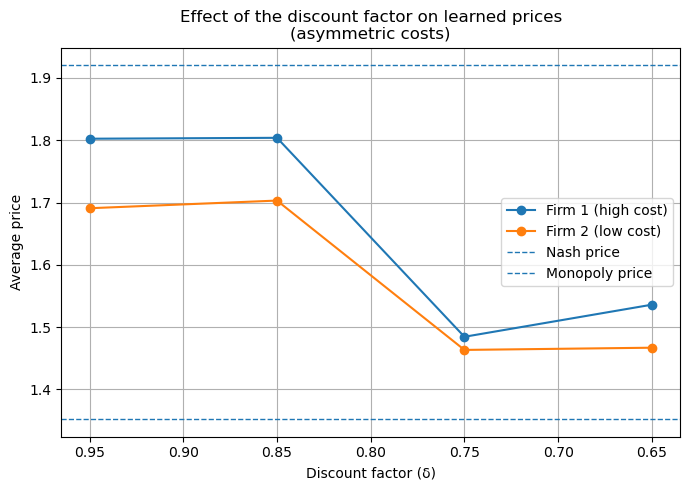

In [16]:
df = pd.DataFrame({
    "δ": [0.95, 0.85, 0.75, 0.65],
    "avg_p1": [1.802365, 1.803810, 1.484512, 1.536024],
    "avg_p2": [1.690803, 1.703099, 1.463421, 1.466975],
})

pN = 1.3525
pM = 1.92

plt.figure(figsize=(7, 5))

plt.plot(df["δ"], df["avg_p1"], marker="o", label="Firm 1 (high cost)")
plt.plot(df["δ"], df["avg_p2"], marker="o", label="Firm 2 (low cost)")

plt.axhline(pN, linestyle="--", linewidth=1, label="Nash price")
plt.axhline(pM, linestyle="--", linewidth=1, label="Monopoly price")

plt.xlabel("Discount factor (δ)")
plt.ylabel("Average price")
plt.title("Effect of the discount factor on learned prices\n(asymmetric costs)")

plt.legend()
plt.grid(True)

plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

This block constructs a dataframe that summarizes the key outcomes from the discount-factor scan. Each row corresponds to a particular value of the discount factor $(\delta)$, and the columns report the average prices learned by firm 1 and firm 2 over the final segment of the simulation window. Firm 1 is the high-cost firm, while firm 2 is the low-cost firm. 

The next block plots the relationship between the discount factor and the average learned price for each firm. Each curve traces outcomes across different values of $(\delta)$, with markers highlighting that the parameter is varied discretely. Economically, these curves show how increased patience alters incentives in the repeated game. A higher discount factor raises the value of future profits, making deviations from high prices less attractive when they lead to future punishments.

Horizontal dashed lines are added to indicate the competitive and cooperative benchmarks. The Nash price represents the outcome of the one-shot pricing game, while the monopoly price provides an upper bound corresponding to perfect coordination. Including these reference lines makes it immediately clear whether the prices learned by the algorithms lie closer to competitive or collusive levels, and how this positioning changes as patience varies.

The figure illustrates a clear and economically intuitive monotonic relationship between patience and learned prices in the asymmetric-cost environment. When the discount factor is high $(\delta = 0.95, 0.85)$, both firms sustain prices that are substantially above the Nash benchmark and close to the monopoly reference, indicating that future-oriented incentives dominate short-run gains from deviation. As patience declines, learned prices drop sharply toward the competitive level, with the most pronounced adjustment occurring between 
$\delta = 0.85$ and $\delta = 0.75$. Throughout, the low-cost firm consistently prices below the high-cost firm, reflecting cost asymmetry in equilibrium behavior, but the gap narrows as coordination weakens. At the lowest values of $\delta$, prices stabilize at intermediate levels above Nash but far from monopoly, suggesting convergence to a lower-price, non-collusive regime rather than persistent cycling.


# Discussion and conclusion


We analyzed a repeated pricing model in which two firms learn optimal pricing strategies through Q-learning under logit demand. Under symmetric marginal costs, firms converge to prices close to the monopoly benchmark,replicating the main finding of Calvano et al.\ (2020) and providing clear evidence of tacit collusion sustained by learning dynamics rather than explicit coordination.

We then examined the effects of asymmetric marginal costs, where one firm enjoys a cost advantage. We find that such asymmetry does not necessarily lead to substantially lower long-run prices. Instead, both firms tend to converge to prices close to the symmetric collusive benchmark, with pricing remaining well above the static Nash level. Even for the cost-advantaged firm, the impact of lower marginal costs on long-run prices and volatility is limited.

Several features of the model help explain why cost asymmetry has only a modest effect on outcomes. First, the logit demand specification and the scale parameter $\mu$ imply smooth price sensitivity, reducing the short-run gains from undercutting. Second, prices are chosen from a discrete grid with $m = 15$ points, restricting undercutting to discrete steps.
Third, firms condition decisions on the previous joint action, enabling implicit punishment strategies.
Finally, the repeated-game structure with discounting makes firms trade off short-run gains against long-run losses from the breakdown of cooperative pricing.

From a policy perspective, these results suggest that cost asymmetries alone may be insufficient to ensure competitive outcomes in markets characterized by repeated interaction and adaptive learning. Even firms with a cost advantage may refrain from aggressive price competition if such behavior undermines future cooperative gains, highlighting the potential persistence of market power in algorithmically mediated settings.

A final modeling assumption is that prices are chosen from a finite set rather than from a continuum. While this discretization is required for tabular Q-learning, it also reflects the fact that firms often adjust prices in discrete steps and allows the learning dynamics to remain tractable. Within this framework, the analysis explains how adaptive learning can sustain collusion and dampen the competitive impact of cost asymmetries in repeated oligopolistic markets.


# Limitations

Despite its insights, the analysis has several limitations that point to natural directions for future research. First, prices are discretized and firms choose from a finite action set. This restriction is necessary for the application of tabular Q-learning but abstracts from continuous price competition. Future work could employ function approximation or alternative reinforcement learning methods that allow firms to operate in continuous action spaces.

Second, firms in the model are homogeneous with respect to their learning process. Both firms rely on the same Q-learning algorithm and share identical learning parameters, such as the learning rate and exploration schedule. In reality, firms may differ substantially in how quickly they adapt or how aggressively they explore. Allowing for heterogeneous learning speeds could shed light on whether collusion is driven by the slowest learner, the most aggressive learner, or by strategic complementarities in learning behavior.

Third, the analysis is limited to a duopoly. While this simplifies the strategic environment and facilitates interpretation, many markets involve more than two firms. Extending the framework to oligopolies with three or more firms would allow for an examination of how learning-based collusion scales with market size and whether additional competitors destabilize cooperative pricing outcomes.

Fourth, the numerical implementation involves several pragmatic choices made to ensure computational feasibility. In particular, the number of random seeds and repetitions was limited, and convergence was assessed using a relatively lenient criterion based on stability over a large final window of iterations rather than exact policy convergence. While this approach captures long-run behavior in practice, future work could explore stricter convergence diagnostics and a broader range of initial conditions.

Finally, to reduce computational burden, several numerical approximations were simplified relative to the original implementation in Calvano et al. (2020). In particular, the grid used to compute best responses and benchmark prices was reduced from a very fine grid to a coarser one, and the maximum number of learning iterations was capped.

In the original paper, simulations with comparable parameter values required on average around 875,000 iterations to converge, with a maximum horizon of approximately two million periods. Under our computational constraints, such settings led to runtimes exceeding fifteen minutes per simulation. We therefore capped the maximum number of iterations at 880,000, guided by the reported convergence rates in the paper.

Similarly, the convergence criterion was relaxed. While Calvano et al. require prices to remain stable over the last 40,000 iterations, we instead assess convergence based on stability over a larger final window of iterations. This approach captures long-run behavior while keeping runtimes manageable.

Results in learning models can be sensitive to random initialization. The original paper therefore relies on multiple independent runs. While we attempted to replicate this approach, computational constraints limited the number of repetitions. Our final results are based on two independent runs per specification, which already suffice to illustrate the main qualitative patterns. Increasing the number of repetitions would further improve robustness.